In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

In [2]:
nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

portfolio = pd.read_csv(
    "../data/processed/portfolio_holdings_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [4]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append([
        fund,
        var_95,
        cvar_95
    ])

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print(
    "var_cvar_report.csv exported successfully"
)

var_cvar_report.csv exported successfully


In [6]:
top5_funds = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

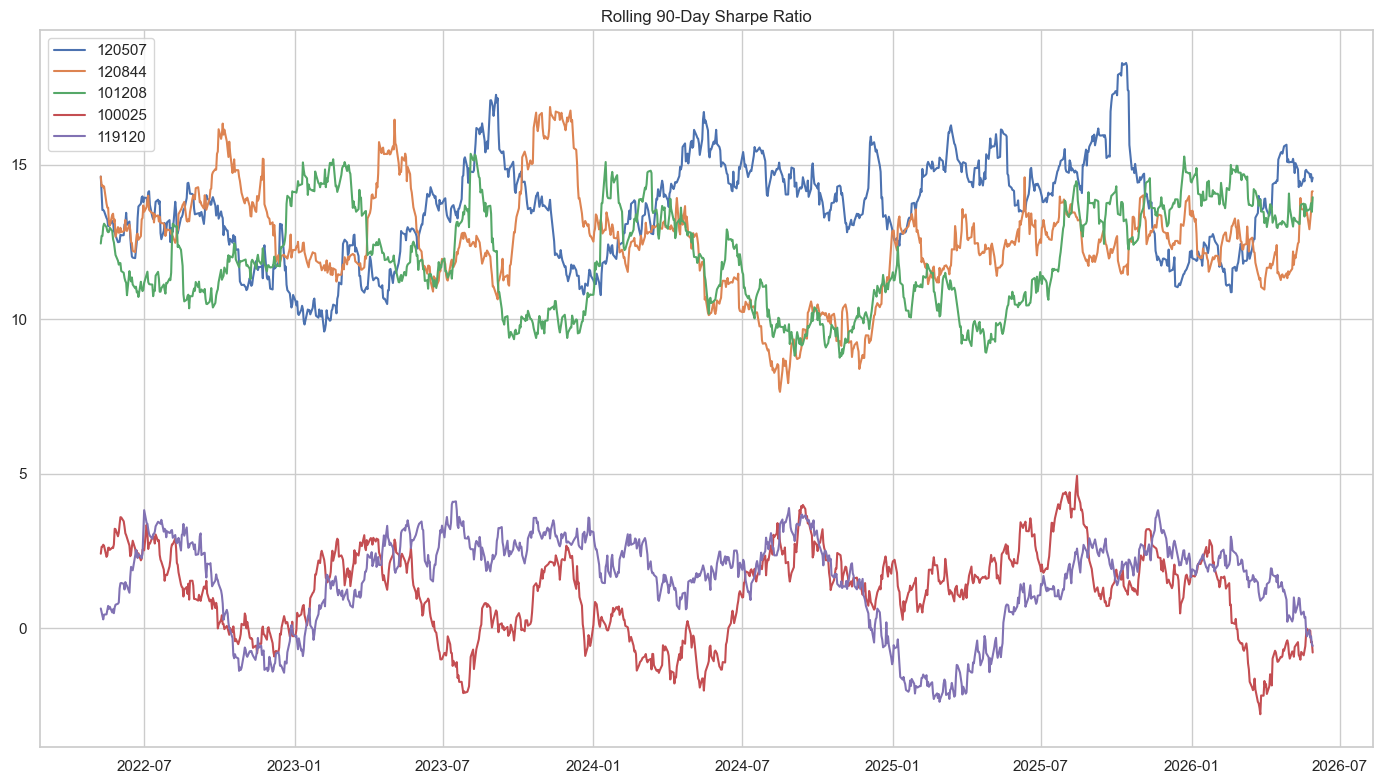

In [7]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png"
)

plt.show()

In [8]:
first_txn = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_txn[
        [
            "investor_id",
            "cohort_year"
        ]
    ],
    on="investor_id"
)

cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [9]:
cohort_fund = (
    transactions
    .groupby(
        [
            "cohort_year",
            "amfi_code"
        ]
    )
    .size()
    .reset_index(name="count")
)

top_fund_per_cohort = (
    cohort_fund
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund_per_cohort

,cohort_year,amfi_code,count
35,2024,148568,874
67,2025,120507,12


In [10]:
sip_txns = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txns = sip_txns.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

at_risk = []

for investor, df in sip_txns.groupby(
    "investor_id"
):

    if len(df) < 6:
        continue

    avg_gap = (
        df["transaction_date"]
        .diff()
        .dt.days
        .mean()
    )

    status = (
        "At Risk"
        if avg_gap > 35
        else "Active"
    )

    at_risk.append([
        investor,
        avg_gap,
        status
    ])

sip_continuity = pd.DataFrame(
    at_risk,
    columns=[
        "investor_id",
        "avg_gap_days",
        "status"
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [11]:
def recommend_funds(risk_level):

    recs = performance[
        performance["risk_grade"]
        .str.contains(
            risk_level,
            case=False,
            na=False
        )
    ]

    return recs.sort_values(
        "sharpe_ratio",
        ascending=False
    )[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio"
        ]
    ].head(3)

In [12]:
recommend_funds("High")

,scheme_name,risk_grade,sharpe_ratio
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,0.98
13,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.98
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96


In [13]:
hhi = (
    portfolio
    .groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x:
        np.sum(
            (x / 100) ** 2
        )
    )
    .reset_index(
        name="HHI"
    )
)

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


### Insight 1

Fund 101207 exhibits the highest downside risk with a VaR (95%) of approximately -2.60%, indicating larger potential one-day losses compared to most schemes.

### Insight 2

The 2024 investor cohort contributed significantly higher total investments (₹349 Cr+) than the 2025 cohort, demonstrating stronger long-term participation.

### Insight 3

SIP continuity analysis identified multiple investors with average transaction gaps exceeding 35 days, classifying them as At-Risk for SIP discontinuation.

### Insight 4

Kotak Flexicap Fund, ICICI Prudential Value Discovery Fund, and Kotak Emerging Equity Fund emerged as the top recommendations for high-risk investors based on Sharpe Ratio.

### Insight 5

Fund 119092 recorded the highest Herfindahl-Hirschman Index (HHI), suggesting a more concentrated portfolio structure relative to peers.